# Red‑Kit Kinematics — Extra Credit Notebook
**Scope**: compute $s(t)$, angles $\alpha(t),\gamma(t)$, their derivatives, ICZV, constraints, and model vs measured overlays.

**Inputs**: CSV with columns `t, Ax, Ay, Bx, By, Cx, Cy`; constants `R, L, theta (rad), xG`.


## 0) Imports & helpers

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

plt.rcParams['figure.figsize'] = (8, 4)

def smooth_and_diff(y, t, window=21, poly=3):
    y = np.asarray(y)
    if window % 2 == 0:
        window += 1
    window = max(window, poly + 2 + (poly + 2) % 2)
    y_s = savgol_filter(y, window_length=window, polyorder=poly, mode='interp')
    dt = np.gradient(t)
    ydot  = np.gradient(y_s, dt)
    yddot = np.gradient(ydot, dt)
    return y_s, ydot, yddot


/Users/shavarshmelikyan/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 1) Load data & set constants

In [2]:
csv_path = 'csv_that_we_should_make_through_experiments.csv'  # <--- change this to your CSV path
R = 0.10
L = 0.25
import numpy as _np
theta = _np.deg2rad(40.0)  # acute angle with ground
xG = 0.0

try:
    df = pd.read_csv(csv_path)
except Exception:
    # make a tiny synthetic demo if file not found
    t = np.linspace(0, 2, 101)
    Cx = 0.2 + 0.05*np.sin(2*np.pi*0.7*t)
    Cy = np.full_like(t, R)
    gamma = 0.5*np.sin(2*np.pi*0.7*t)
    Bx = Cx + R*np.cos(gamma)
    By = Cy + R*np.sin(gamma)
    u_theta = np.array([-np.cos(theta), np.sin(theta)])
    W0 = np.array([xG, 0.0])
    s_demo = 0.15 + 0.05*np.sin(2*np.pi*0.5*t)
    Axy = (W0[None,:] + s_demo[:,None]*u_theta[None,:])
    Ax, Ay = Axy[:,0], Axy[:,1]
    df = pd.DataFrame({'t': t, 'Ax': Ax, 'Ay': Ay, 'Bx': Bx, 'By': By, 'Cx': Cx, 'Cy': Cy})

t  = df['t' ].to_numpy()
Ax = df['Ax'].to_numpy(); Ay = df['Ay'].to_numpy()
Bx = df['Bx'].to_numpy(); By = df['By'].to_numpy()
Cx = df['Cx'].to_numpy(); Cy = df['Cy'].to_numpy()
print(df.head())


      t        Ax        Ay        Bx        By        Cx   Cy
0  0.00 -0.114907  0.096418  0.300000  0.100000  0.200000  0.1
1  0.02 -0.117312  0.098436  0.304296  0.104391  0.204393  0.1
2  0.04 -0.119707  0.100446  0.308368  0.108740  0.208751  0.1
3  0.06 -0.122084  0.102440  0.312193  0.113005  0.213042  0.1
4  0.08 -0.124432  0.104411  0.315751  0.117147  0.217232  0.1


## 2) Geometry & primary variables

In [3]:
u_theta = np.array([-np.cos(theta), np.sin(theta)])
W0 = np.array([xG, 0.0])
A = np.vstack([Ax, Ay]).T
B = np.vstack([Bx, By]).T
C = np.vstack([Cx, Cy]).T
gamma_raw = np.arctan2(By - Cy, Bx - Cx)
alpha_raw = np.arctan2(By - Ay, Bx - Ax)
gamma = np.unwrap(gamma_raw)
alpha = np.unwrap(alpha_raw)
s = (A - W0[None,:]) @ u_theta
print('u_theta:', u_theta, '\nFirst s:', s[:5])


u_theta: [-0.76604444  0.64278761] 
First s: [0.15       0.15313953 0.15626666 0.15936907 0.16243449]


## 3) Smoothing & derivatives

In [4]:
gamma_s, gammadot, gammaddot = smooth_and_diff(gamma, t)
alpha_s, alphadot, alphaddot = smooth_and_diff(alpha, t)
s_s, sdot, sddot = smooth_and_diff(s, t)
xC_s, xCdot, xCddot = smooth_and_diff(Cx, t)
print('Derivatives computed.')


Derivatives computed.


/Users/shavarshmelikyan/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:1215: RuntimeWarning: divide by zero encountered in true_divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/Users/shavarshmelikyan/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:1215: RuntimeWarning: invalid value encountered in true_divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/Users/shavarshmelikyan/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:1216: RuntimeWarning: divide by zero encountered in true_divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/shavarshmelikyan/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:1216: RuntimeWarning: invalid value encountered in true_divide
  b = (dx2 - dx1) / (dx1 * dx2)
/Users/shavarshmelikyan/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:1217: RuntimeWarning: divide by zero encountered in true_divide
  c = dx1 / (dx2 * (dx1 + dx2))
/Users/shavarshmelikyan/opt/anaconda3/lib/python3.9/sit

## 4) ICZV of the rod

In [5]:
vA = (sdot[:,None] * u_theta[None,:])
k_cross_vA = np.column_stack([-vA[:,1], vA[:,0]])
eps = 1e-8
alphadot_safe = np.where(np.abs(alphadot) < eps, np.nan, alphadot)
rAP = (k_cross_vA.T / alphadot_safe).T
P_iczv = A + rAP
print('ICZV ready (NaN when alphadot~0).')


ICZV ready (NaN when alphadot~0).


/var/folders/8h/f8h6db8n04z7dkdqqxfyt7jm0000gn/T/ipykernel_3694/1456093842.py:5: RuntimeWarning: invalid value encountered in true_divide
  rAP = (k_cross_vA.T / alphadot_safe).T


## 5) Constraint residuals

/var/folders/8h/f8h6db8n04z7dkdqqxfyt7jm0000gn/T/ipykernel_3694/2550527464.py:1: RuntimeWarning: invalid value encountered in subtract
  roll_res = xCdot - R * gammadot


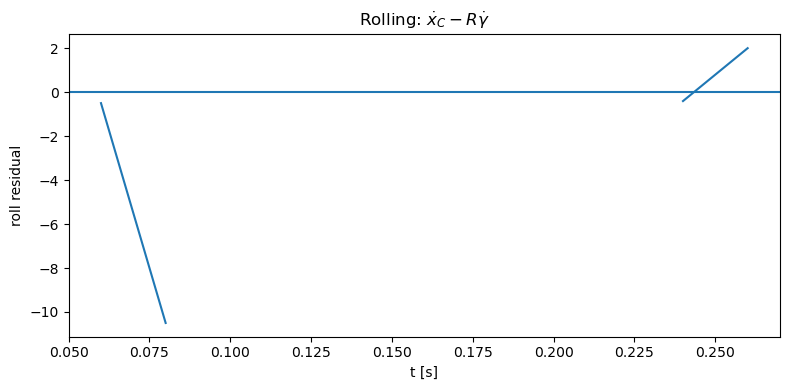

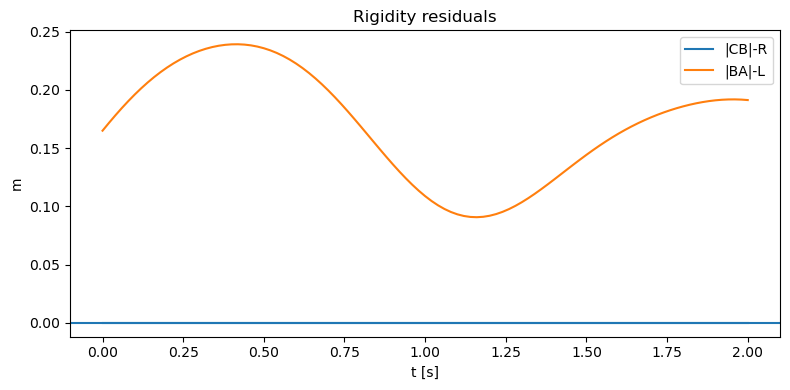

In [6]:
roll_res = xCdot - R * gammadot
CB_len = np.linalg.norm(B - C, axis=1)
BA_len = np.linalg.norm(A - B, axis=1)
rigid_CB_res = CB_len - R
rigid_BA_res = BA_len - L

plt.figure(); plt.plot(t, roll_res); plt.axhline(0)
plt.xlabel('t [s]'); plt.ylabel('roll residual'); plt.title(r'Rolling: $\dot{x}_C - R\dot{\gamma}$'); plt.tight_layout()

plt.figure(); plt.plot(t, rigid_CB_res, label='|CB|-R'); plt.plot(t, rigid_BA_res, label='|BA|-L')
plt.axhline(0); plt.xlabel('t [s]'); plt.ylabel('m'); plt.title('Rigidity residuals'); plt.legend(); plt.tight_layout()


## 6) Velocity‑level model vs measured

/var/folders/8h/f8h6db8n04z7dkdqqxfyt7jm0000gn/T/ipykernel_3694/3132406754.py:3: RuntimeWarning: invalid value encountered in subtract
  rhs1 = xCdot - R * gammadot * np.sin(gamma)


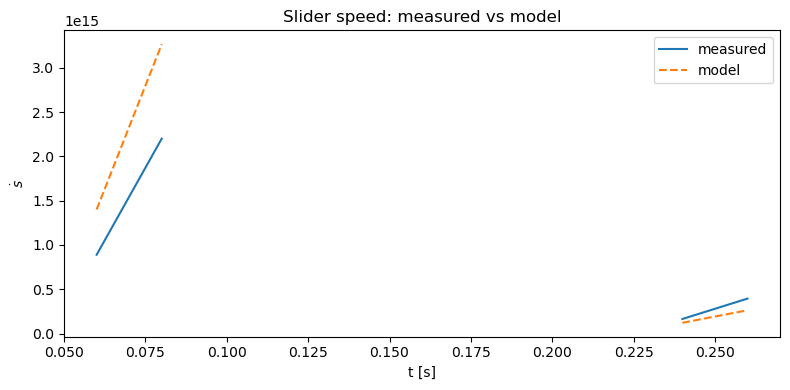

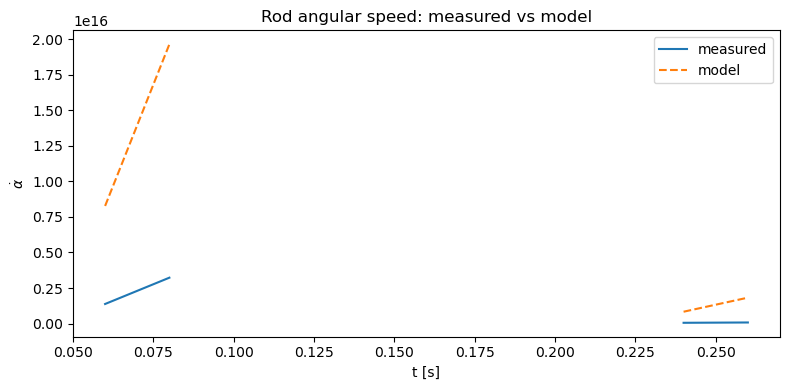

In [7]:
def solve_vel_level(xCdot, gammadot, gamma, alpha, L, theta):
    cT = np.cos(np.pi - theta); sT = np.sin(np.pi - theta)
    rhs1 = xCdot - R * gammadot * np.sin(gamma)
    rhs2 = R * gammadot * np.cos(gamma)
    det = L * np.cos(alpha - theta)
    sdot_model     = (  L*np.cos(alpha)*rhs1 + L*np.sin(alpha)*rhs2 ) / det
    alphadot_model = ( sT*rhs1 - cT*rhs2 ) / det
    return sdot_model, alphadot_model

sdot_mod, alphadot_mod = solve_vel_level(xCdot, gammadot, gamma_s, alpha_s, L, theta)

plt.figure(); plt.plot(t, sdot, label='measured'); plt.plot(t, sdot_mod, linestyle='--', label='model')
plt.xlabel('t [s]'); plt.ylabel(r'$\dot{s}$'); plt.title('Slider speed: measured vs model'); plt.legend(); plt.tight_layout()

plt.figure(); plt.plot(t, alphadot, label='measured'); plt.plot(t, alphadot_mod, linestyle='--', label='model')
plt.xlabel('t [s]'); plt.ylabel(r'$\dot{\alpha}$'); plt.title('Rod angular speed: measured vs model'); plt.legend(); plt.tight_layout()


## 7) Acceleration‑level model vs measured

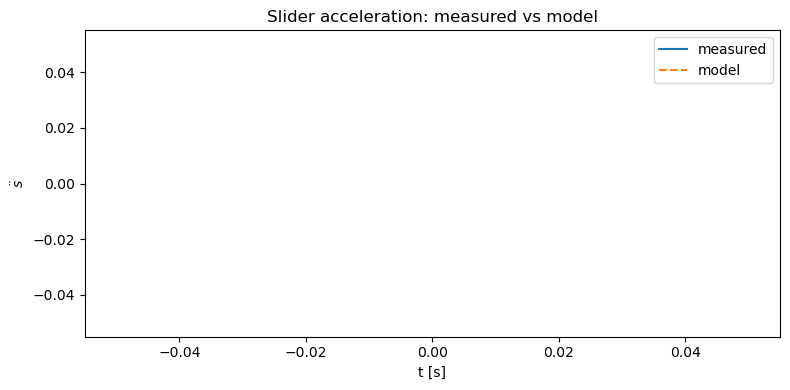

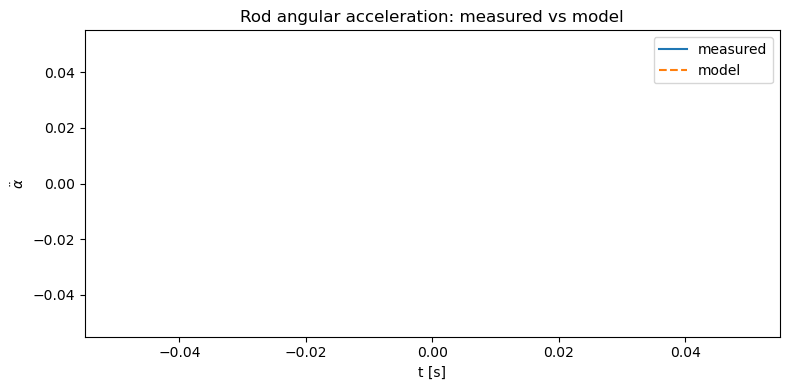

In [9]:
def solve_acc_level(xCddot, gammadot, gammaddot, gamma, alpha, alphadot, L, theta):
    cT = np.cos(np.pi - theta); sT = np.sin(np.pi - theta)
    aBx = R*(gammaddot*(1 - np.sin(gamma)) - gammadot**2 * np.cos(gamma))
    aBy = R*(gammaddot*np.cos(gamma)        - gammadot**2 * np.sin(gamma))
    rhs1 = aBx + L*(alphadot**2)*np.cos(alpha)
    rhs2 = aBy + L*(alphadot**2)*np.sin(alpha)
    det = L * np.cos(alpha - theta)
    sddot_model     = (  L*np.cos(alpha)*rhs1 + L*np.sin(alpha)*rhs2 ) / det
    alphaddot_model = ( sT*rhs1 - cT*rhs2 ) / det
    return sddot_model, alphaddot_model

sddot_mod, alphaddot_mod = solve_acc_level(xCddot, gammadot, gammaddot, gamma_s, alpha_s, alphadot, L, theta)

plt.figure(); plt.plot(t, sddot, label='measured'); plt.plot(t, sddot_mod, linestyle='--', label='model')
plt.xlabel('t [s]'); plt.ylabel(r'$\ddot{s}$'); plt.title('Slider acceleration: measured vs model'); plt.legend(); plt.tight_layout()

plt.figure(); plt.plot(t, alphaddot, label='measured'); plt.plot(t, alphaddot_mod, linestyle='--', label='model')
plt.xlabel('t [s]'); plt.ylabel(r'$\ddot{\alpha}$'); plt.title('Rod angular acceleration: measured vs model'); plt.legend(); plt.tight_layout()


## 8) (Optional) Animation

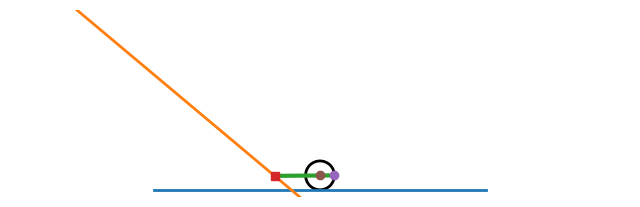

In [10]:
from matplotlib.animation import FuncAnimation
wall_pts = np.vstack([W0 - 5*u_theta, W0 + 5*u_theta])
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot([np.min(Cx)-R-1, np.max(Cx)+R+1], [0,0], linewidth=2)
ax.plot(wall_pts[:,0], wall_pts[:,1], linewidth=2)
disc = plt.Circle((Cx[0], Cy[0]), R, fill=False, linewidth=2)
ax.add_patch(disc)
rod_line, = ax.plot([Ax[0], Bx[0]], [Ay[0], By[0]], linewidth=3)
Apt, = ax.plot(Ax[0], Ay[0], 's')
Bpt, = ax.plot(Bx[0], By[0], 'o')
Cpt, = ax.plot(Cx[0], Cy[0], 'o')
Ppt, = ax.plot([], [], 'x')
ax.set_aspect('equal', 'box')
ax.set_xlim(np.min(Cx)-R-2, np.max(Cx)+R+2)
ax.set_ylim(-0.5*R, np.max([Ay.max(), By.max(), Cy.max()])+R+1)
ax.axis('off')
def update(k):
    disc.center = (Cx[k], Cy[k])
    rod_line.set_data([Ax[k], Bx[k]], [Ay[k], By[k]])
    Apt.set_data([Ax[k]], [Ay[k]])
    Bpt.set_data([Bx[k]], [By[k]])
    Cpt.set_data([Cx[k]], [Cy[k]])
    if k < len(P_iczv) and not np.any(np.isnan(P_iczv[k])):
        Ppt.set_data([P_iczv[k,0]], [P_iczv[k,1]])
    else:
        Ppt.set_data([], [])
    return disc, rod_line, Apt, Bpt, Cpt, Ppt
ani = FuncAnimation(fig, update, frames=len(t), interval=30, blit=True)
# ani.save('/mnt/data/redkit_anim.mp4', fps=30)  # requires ffmpeg
plt.show()
